# Hourly Shift Model 90-Day Impact

This notebook reuses the shared `hourly_shift_model_v2.py` setup, simulates the current hourly shift model across a non-overlapping 90-day period, and visualizes baseline versus shifted household consumption.

In [51]:
from copy import deepcopy

import matplotlib.pyplot as plt
import pandas as pd

from hourly_shift_model_v2 import (
    DECISION_WEIGHTS,
    FORECAST_HORIZON_HOURS,
    HOUSEHOLD_SHARE_OF_SYSTEM,
    SEGMENT_ASSUMPTIONS,
    assemble_window_for_issue_time,
    build_historical_segment_capacity,
    build_issue_catalog,
    build_shift_plan,
    load_predictions,
    load_system_load,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

In [52]:
SIMULATION_DAYS = 90
NON_OVERLAPPING_WINDOW_DAYS = 5
SIMULATION_WINDOWS = SIMULATION_DAYS // NON_OVERLAPPING_WINDOW_DAYS

preds = load_predictions()
system_load = load_system_load()
issue_catalog = build_issue_catalog(preds)
daily_issue_times = issue_catalog.loc[
    issue_catalog["issue_time"].dt.hour == 12,
    "issue_time",
].reset_index(drop=True)

simulation_daily_issue_times = daily_issue_times.tail(SIMULATION_DAYS).reset_index(drop=True)
simulation_issue_times = simulation_daily_issue_times.iloc[::NON_OVERLAPPING_WINDOW_DAYS].reset_index(drop=True)

if len(simulation_issue_times) != SIMULATION_WINDOWS:
    raise ValueError(
        f"Expected {SIMULATION_WINDOWS} windows for {SIMULATION_DAYS} days, found {len(simulation_issue_times)}."
    )

display(
    pd.Series(
        {
            "simulation_days": SIMULATION_DAYS,
            "window_stride_days": NON_OVERLAPPING_WINDOW_DAYS,
            "simulation_windows": int(len(simulation_issue_times)),
            "simulated_hours": int(len(simulation_issue_times) * FORECAST_HORIZON_HOURS),
            "start_issue_time": simulation_issue_times.iloc[0],
            "end_issue_time": simulation_issue_times.iloc[-1],
        }
    ).to_frame("value")
)

,value
simulation_days,90
window_stride_days,5
simulation_windows,18
simulated_hours,2160
start_issue_time,2026-01-03 12:00:00
end_issue_time,2026-04-03 12:00:00


In [53]:
segment_assumptions = deepcopy(SEGMENT_ASSUMPTIONS)
historical_segment_capacity = build_historical_segment_capacity(
    system_load=system_load,
    segment_assumptions=segment_assumptions,
    household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
)

scenario_profiles = []
total_shifted_energy_mwh = 0.0
total_shift_events = 0

for issue_time in simulation_issue_times:
    window_df = assemble_window_for_issue_time(
        issue_time=issue_time,
        preds=preds,
        system_load=system_load,
        household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
        segment_assumptions=segment_assumptions,
    )
    profile_df, shifts_df = build_shift_plan(
        window_df=window_df,
        segment_assumptions=segment_assumptions,
        decision_weights=DECISION_WEIGHTS,
        historical_segment_capacity=historical_segment_capacity,
    )
    profile_df = profile_df.copy()
    profile_df["issue_time"] = pd.Timestamp(issue_time)
    scenario_profiles.append(profile_df)

    if not shifts_df.empty:
        total_shifted_energy_mwh += float(shifts_df["shift_mwh"].sum())
        total_shift_events += int(len(shifts_df))

simulation_profiles_df = (
    pd.concat(scenario_profiles, ignore_index=True)
    .sort_values("target_time")
    .drop_duplicates(subset=["target_time"], keep="first")
    .reset_index(drop=True)
)
simulation_profiles_df["impact_mwh"] = (
    simulation_profiles_df["household_load_mwh"] - simulation_profiles_df["shifted_household_load_mwh"]
)

display(
    pd.Series(
        {
            "simulation_start": simulation_profiles_df["target_time"].min(),
            "simulation_end": simulation_profiles_df["target_time"].max(),
            "hours_in_plot": int(len(simulation_profiles_df)),
            "total_shift_events": total_shift_events,
            "total_shifted_energy_mwh": round(total_shifted_energy_mwh, 2),
            "avg_impact_mwh": round(simulation_profiles_df["impact_mwh"].abs().mean(), 4),
        }
    ).to_frame("value")
)

display(
    simulation_profiles_df[
        [
            "target_time",
            "household_load_mwh",
            "shifted_household_load_mwh",
            "impact_mwh",
        ]
    ].head()
)

,value
simulation_start,2026-01-03 13:00:00
simulation_end,2026-04-08 12:00:00
hours_in_plot,2160
total_shift_events,3020
total_shifted_energy_mwh,32124.85
avg_impact_mwh,24.5626


,target_time,household_load_mwh,shifted_household_load_mwh,impact_mwh
0,2026-01-03 13:00:00,999.457891,849.539208,149.918684
1,2026-01-03 14:00:00,997.220981,850.735070,146.485911
2,2026-01-03 15:00:00,1003.974568,870.237236,133.737332
3,2026-01-03 16:00:00,1042.447616,980.505046,61.942570
4,2026-01-03 17:00:00,1096.984420,1020.644530,76.339889


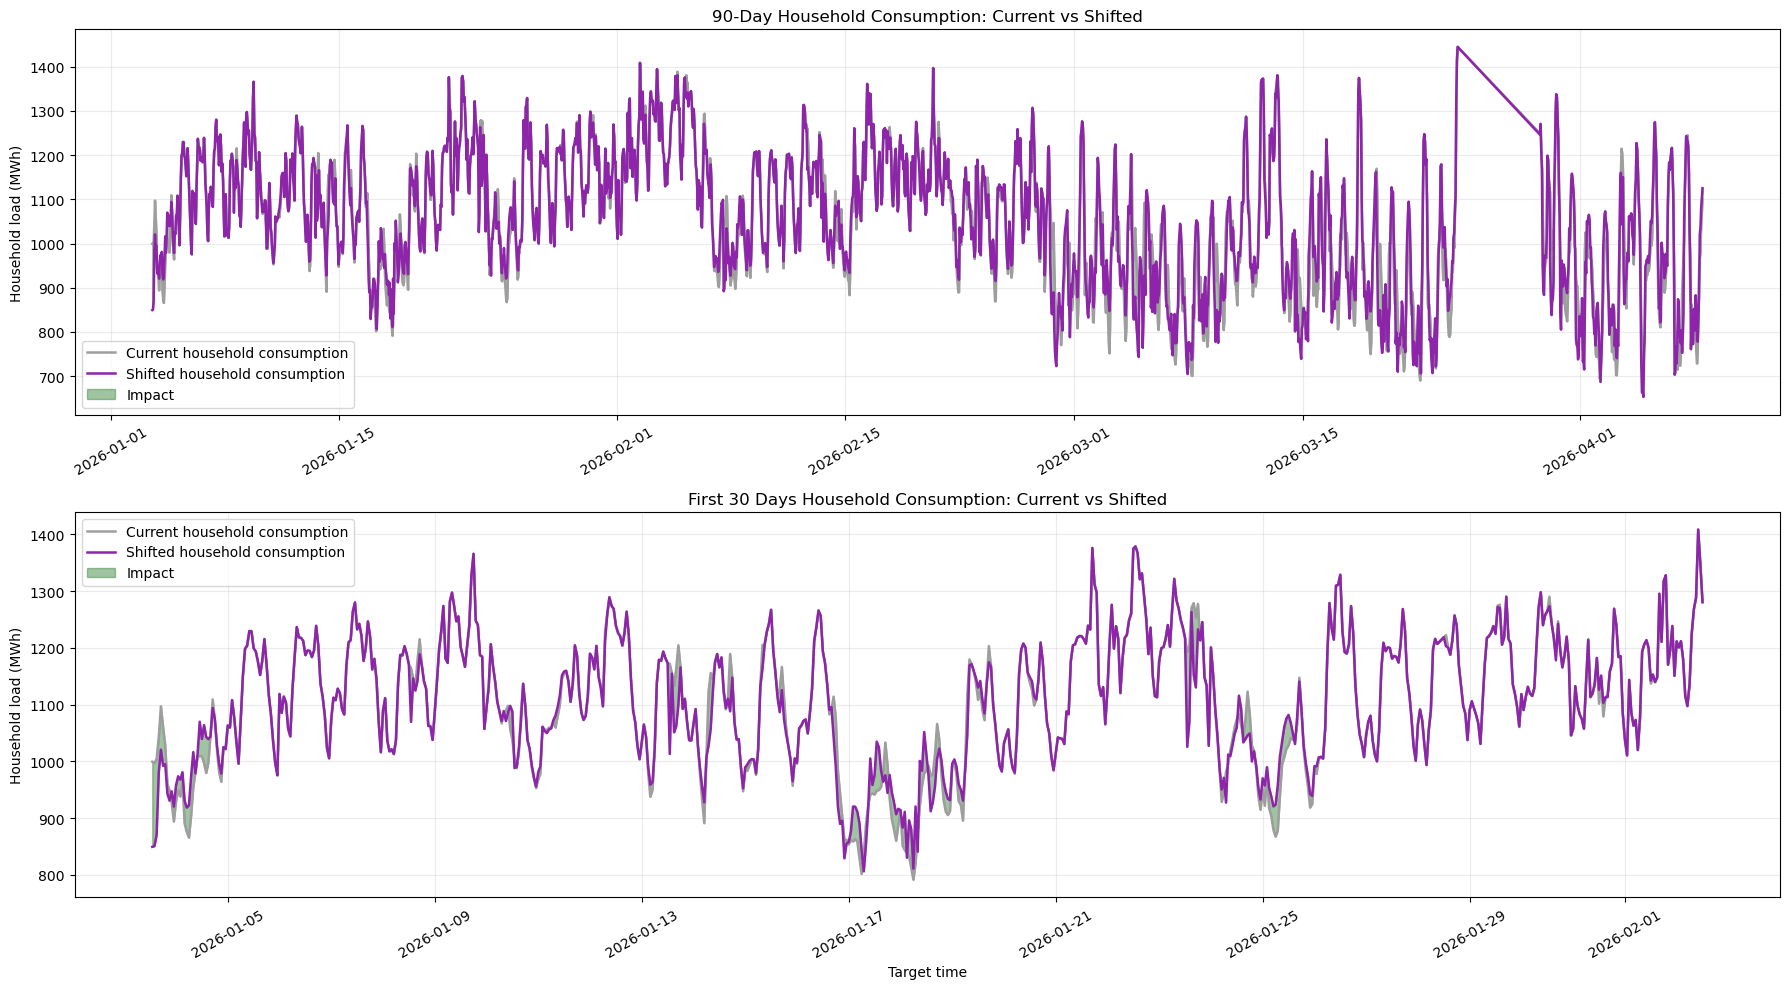

In [54]:
plot_df = simulation_profiles_df.copy()
first_30d_end = plot_df["target_time"].min() + pd.Timedelta(days=30)
plot_30d_df = plot_df.loc[plot_df["target_time"] < first_30d_end].copy()
impact_color = "#2E7D32"

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharey=False)

for ax, data, title in [
    (axes[0], plot_df, "90-Day Household Consumption: Current vs Shifted"),
    (axes[1], plot_30d_df, "First 30 Days Household Consumption: Current vs Shifted"),
]:
    ax.plot(
        data["target_time"],
        data["household_load_mwh"],
        color="#9E9E9E",
        linewidth=1.8,
        label="Current household consumption",
    )
    ax.plot(
        data["target_time"],
        data["shifted_household_load_mwh"],
        color="#8E24AA",
        linewidth=1.8,
        label="Shifted household consumption",
    )
    ax.fill_between(
        data["target_time"],
        data["household_load_mwh"],
        data["shifted_household_load_mwh"],
        color=impact_color,
        alpha=0.45,
        label="Impact",
    )
    ax.set_title(title)
    ax.set_ylabel("Household load (MWh)")
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].tick_params(axis="x", rotation=30)
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_xlabel("Target time")
plt.tight_layout()

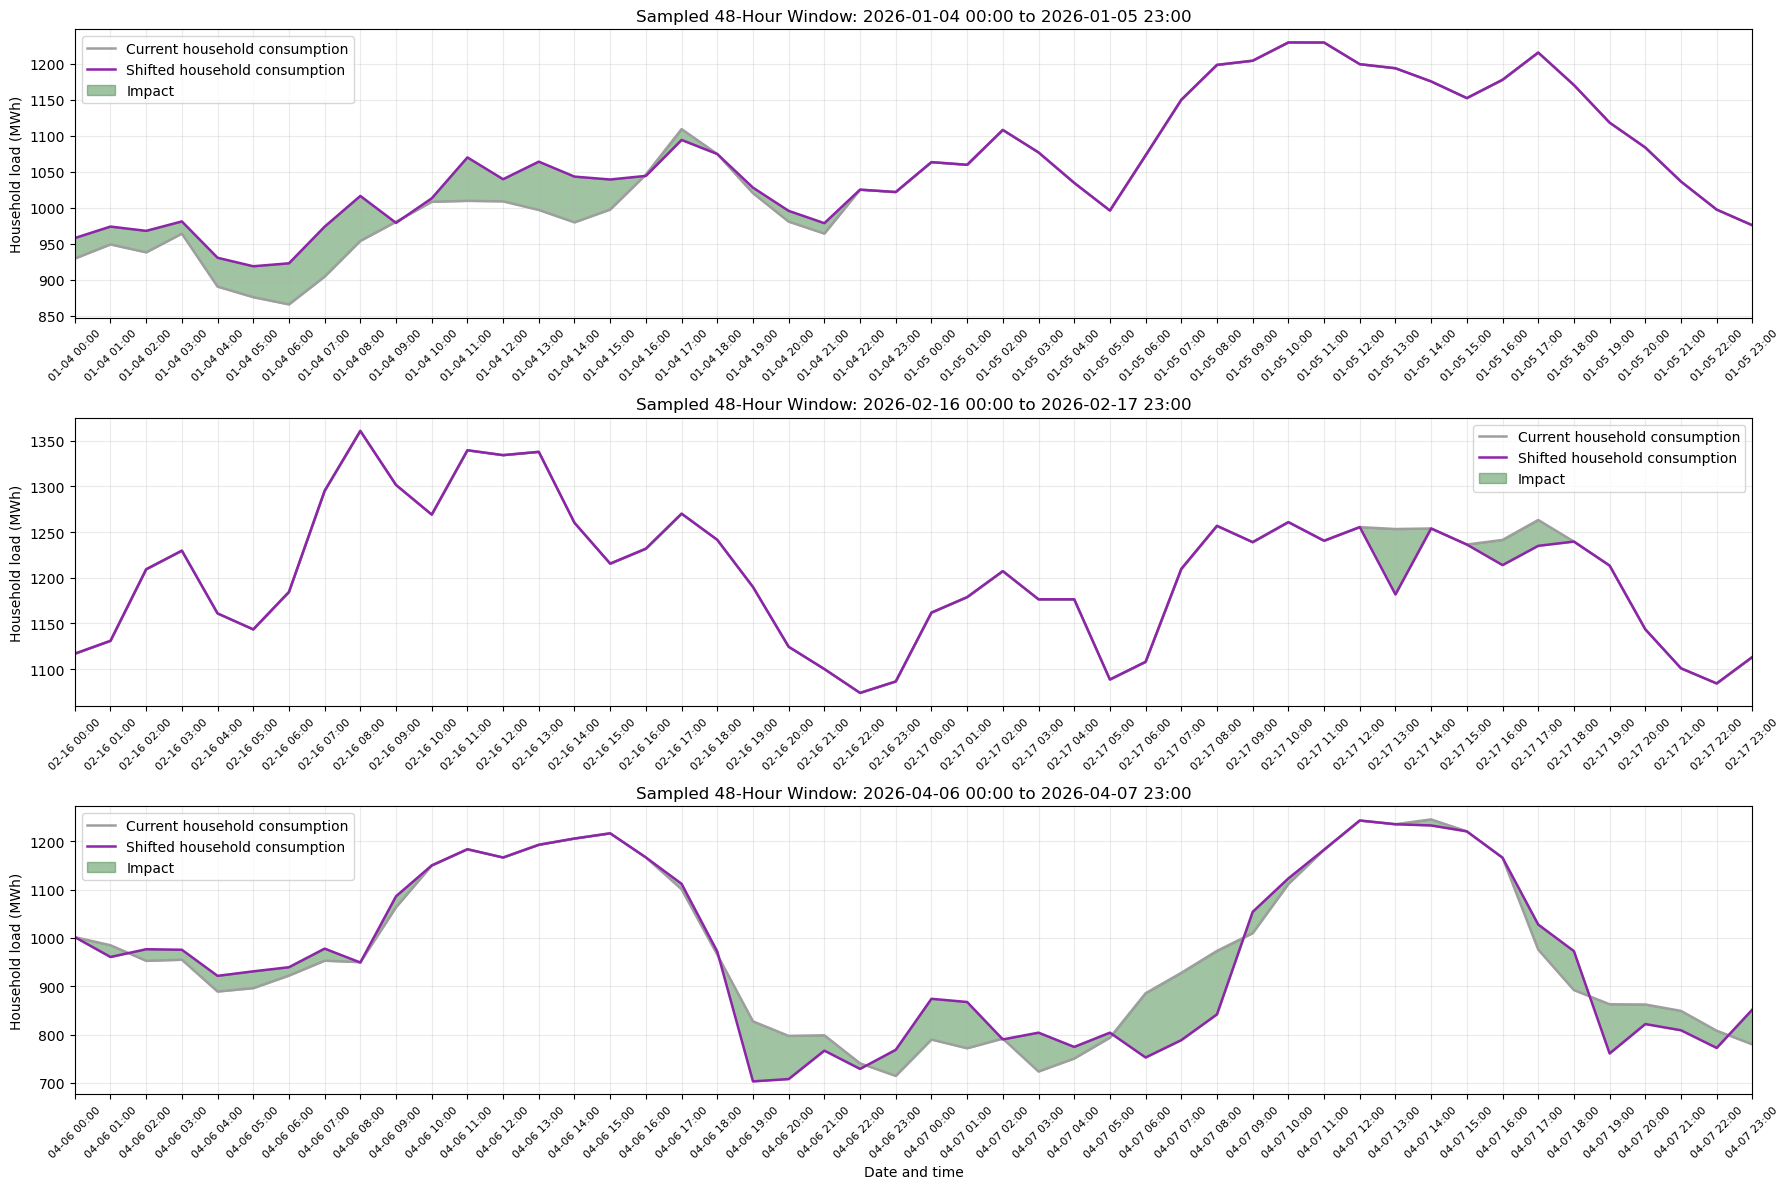

In [55]:
import matplotlib.dates as mdates

sample_plot_df = simulation_profiles_df.copy()
day_counts = (
    sample_plot_df.assign(day=sample_plot_df["target_time"].dt.normalize())
    .groupby("day")
    .size()
    .reset_index(name="n_hours")
)
full_days = day_counts.loc[day_counts["n_hours"] == 24, "day"].reset_index(drop=True)
valid_window_starts = full_days[
    full_days.shift(-1) == (full_days + pd.Timedelta(days=1))
].reset_index(drop=True)

if len(valid_window_starts) < 3:
    raise ValueError(f"Expected at least 3 full 48-hour windows, found {len(valid_window_starts)}.")

sampled_window_positions = [0, len(valid_window_starts) // 2, len(valid_window_starts) - 1]
sampled_window_starts = valid_window_starts.iloc[sampled_window_positions].tolist()
impact_color = "#2E7D32"

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharey=False)

for ax, window_start in zip(axes, sampled_window_starts):
    window_start = pd.Timestamp(window_start)
    window_end = window_start + pd.Timedelta(hours=47)
    window_df = sample_plot_df.loc[
        (sample_plot_df["target_time"] >= window_start)
        & (sample_plot_df["target_time"] <= window_end)
    ].copy()

    ax.plot(
        window_df["target_time"],
        window_df["household_load_mwh"],
        color="#9E9E9E",
        linewidth=1.8,
        label="Current household consumption",
    )
    ax.plot(
        window_df["target_time"],
        window_df["shifted_household_load_mwh"],
        color="#8E24AA",
        linewidth=1.8,
        label="Shifted household consumption",
    )
    ax.fill_between(
        window_df["target_time"],
        window_df["household_load_mwh"],
        window_df["shifted_household_load_mwh"],
        color=impact_color,
        alpha=0.45,
        label="Impact",
    )
    ax.set_title(
        f"Sampled 48-Hour Window: {window_start:%Y-%m-%d %H:%M} to {window_end:%Y-%m-%d %H:%M}"
    )
    ax.set_ylabel("Household load (MWh)")
    ax.set_xlim(window_start, window_end)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Date and time")
plt.tight_layout()

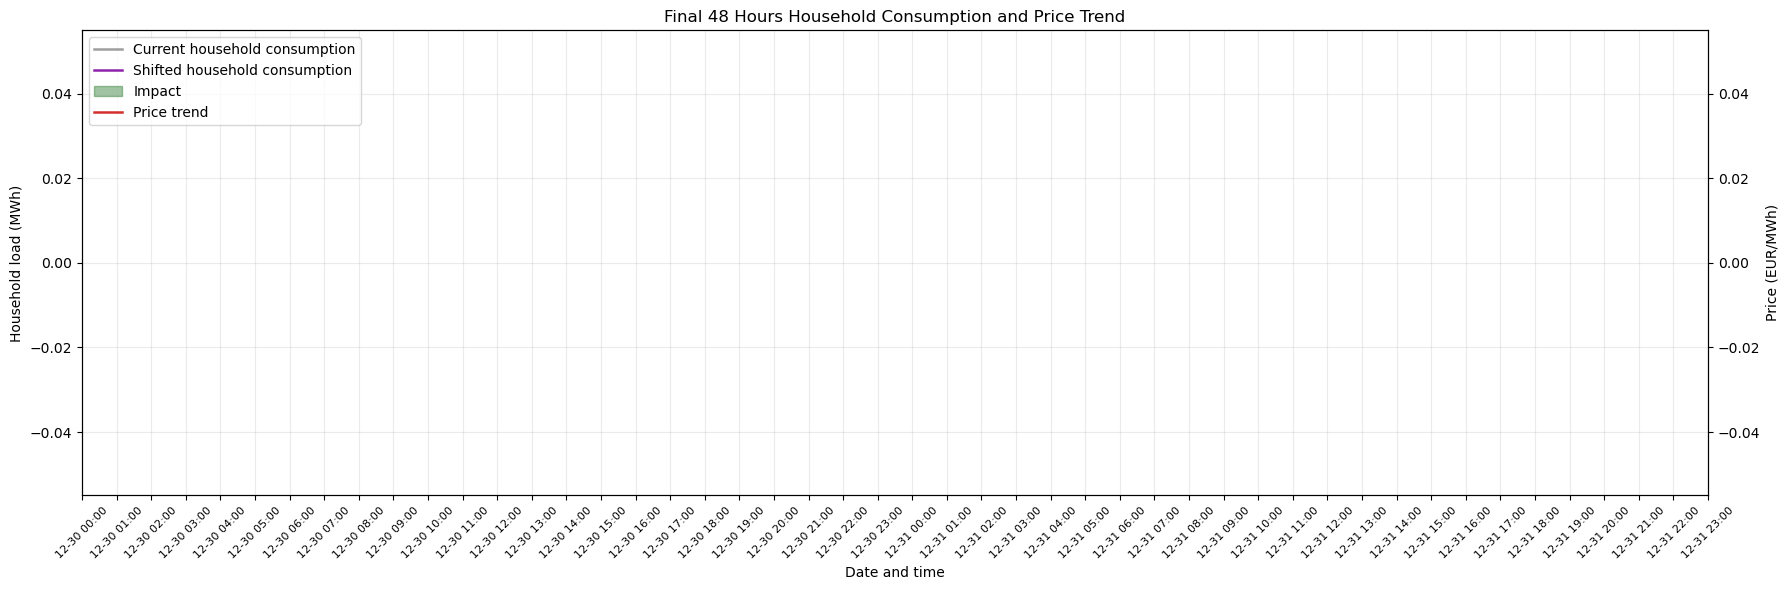

In [57]:
import matplotlib.dates as mdates

last_window_start = pd.Timestamp("2025-12-30 00:00:00")
last_window_end = pd.Timestamp("2025-12-31 23:00:00")
last_window_df = simulation_profiles_df.loc[
    (simulation_profiles_df["target_time"] >= last_window_start)
    & (simulation_profiles_df["target_time"] <= last_window_end)
].copy()

# if len(last_window_df) != 48:
#     raise ValueError(
#         f"Expected 48 hourly rows for the final window, found {len(last_window_df)}."
#     )

impact_color = "#2E7D32"
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    last_window_df["target_time"],
    last_window_df["household_load_mwh"],
    color="#9E9E9E",
    linewidth=1.8,
    label="Current household consumption",
)
ax.plot(
    last_window_df["target_time"],
    last_window_df["shifted_household_load_mwh"],
    color="#8E24AA",
    linewidth=1.8,
    label="Shifted household consumption",
)
ax.fill_between(
    last_window_df["target_time"],
    last_window_df["household_load_mwh"],
    last_window_df["shifted_household_load_mwh"],
    color=impact_color,
    alpha=0.45,
    label="Impact",
)
ax.set_title("Final 48 Hours Household Consumption and Price Trend")
ax.set_ylabel("Household load (MWh)")
ax.set_xlim(last_window_start, last_window_end)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.grid(alpha=0.25)

ax_price = ax.twinx()
ax_price.plot(
    last_window_df["target_time"],
    last_window_df["DayAheadPriceEUR"],
    color="#D32F2F",
    linewidth=1.8,
    label="Price trend",
)
ax_price.set_ylabel("Price (EUR/MWh)")

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_price.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper left")
ax.set_xlabel("Date and time")
plt.tight_layout()

,baseline_p95_mwh,current_above_p95_mwh,impact_mwh,shifted_above_p95_mwh,peak_reduction_pct,current_hours_above_p95,shifted_hours_above_p95
case,,,,,,,
Total household,1286.74,4832.13,273.04,4559.09,5.65,108,102
Total system energy,3899.21,14642.80,330.54,14312.26,2.26,108,104


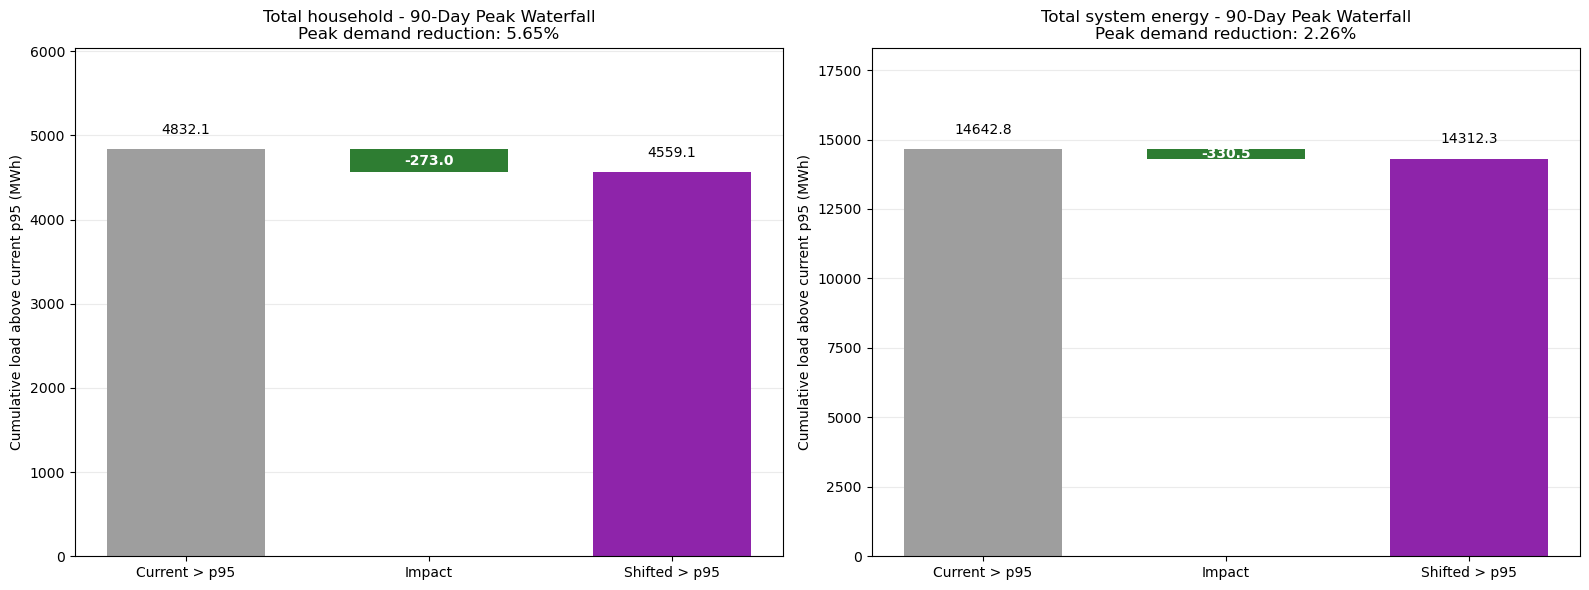

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

required_cols = [
    "household_load_mwh",
    "shifted_household_load_mwh",
    "system_load_mwh",
    "shifted_system_load_mwh",
]

missing_cols = [col for col in required_cols if col not in simulation_profiles_df.columns]
if missing_cols:
    raise KeyError(
        "simulation_profiles_df is missing required columns for the peak waterfall: "
        + ", ".join(missing_cols)
    )

current_color = "#9E9E9E"
shifted_color = "#8E24AA"
impact_color = "#2E7D32"


def compute_peak_excess_summary(df: pd.DataFrame, baseline_col: str, shifted_col: str, label: str) -> dict:
    baseline_p95 = float(df[baseline_col].quantile(0.95))
    current_excess = (df[baseline_col] - baseline_p95).clip(lower=0)
    shifted_excess = (df[shifted_col] - baseline_p95).clip(lower=0)

    current_total = float(current_excess.sum())
    shifted_total = float(shifted_excess.sum())
    impact_total = current_total - shifted_total
    reduction_pct = 100.0 * impact_total / current_total if current_total > 0 else 0.0

    return {
        "case": label,
        "baseline_p95_mwh": baseline_p95,
        "current_above_p95_mwh": current_total,
        "impact_mwh": impact_total,
        "shifted_above_p95_mwh": shifted_total,
        "peak_reduction_pct": reduction_pct,
        "current_hours_above_p95": int((df[baseline_col] > baseline_p95).sum()),
        "shifted_hours_above_p95": int((df[shifted_col] > baseline_p95).sum()),
    }


peak_excess_summary_df = pd.DataFrame(
    [
        compute_peak_excess_summary(
            simulation_profiles_df,
            baseline_col="household_load_mwh",
            shifted_col="shifted_household_load_mwh",
            label="Total household",
        ),
        compute_peak_excess_summary(
            simulation_profiles_df,
            baseline_col="system_load_mwh",
            shifted_col="shifted_system_load_mwh",
            label="Total system energy",
        ),
    ]
)

display(
    peak_excess_summary_df.assign(
        baseline_p95_mwh=lambda df: df["baseline_p95_mwh"].round(2),
        current_above_p95_mwh=lambda df: df["current_above_p95_mwh"].round(2),
        impact_mwh=lambda df: df["impact_mwh"].round(2),
        shifted_above_p95_mwh=lambda df: df["shifted_above_p95_mwh"].round(2),
        peak_reduction_pct=lambda df: df["peak_reduction_pct"].round(2),
    ).set_index("case")
)


def plot_peak_excess_waterfall(ax, row: pd.Series) -> None:
    current_total = float(row["current_above_p95_mwh"])
    impact_total = float(row["impact_mwh"])
    shifted_total = float(row["shifted_above_p95_mwh"])
    scale = max(current_total, shifted_total, 1.0)

    ax.bar(0, current_total, width=0.65, color=current_color)
    ax.bar(1, -impact_total, width=0.65, bottom=current_total, color=impact_color)
    ax.bar(2, shifted_total, width=0.65, color=shifted_color)

    ax.text(0, current_total + scale * 0.03, f"{current_total:.1f}", ha="center", va="bottom")
    ax.text(
        1,
        current_total - impact_total / 2,
        f"-{impact_total:.1f}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )
    ax.text(2, shifted_total + scale * 0.03, f"{shifted_total:.1f}", ha="center", va="bottom")

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Current > p95", "Impact", "Shifted > p95"])
    ax.set_ylabel("Cumulative load above current p95 (MWh)")
    ax.set_title(
        f"{row['case']} - 90-Day Peak Waterfall\nPeak demand reduction: {row['peak_reduction_pct']:.2f}%"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_ylim(0, scale * 1.25)


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, (_, row) in zip(axes, peak_excess_summary_df.iterrows()):
    plot_peak_excess_waterfall(ax, row)

plt.tight_layout()